In [20]:
from tqdm.notebook import tqdm
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# # import A03simple_example_template.py with reload
# %load_ext autoreload
# %autoreload 2
# from A03simple_example_template import sample_reverse

In [22]:
# generate a dataset of 1D data from a mixture of two Gaussians
# this is a simple example, but you can use any distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

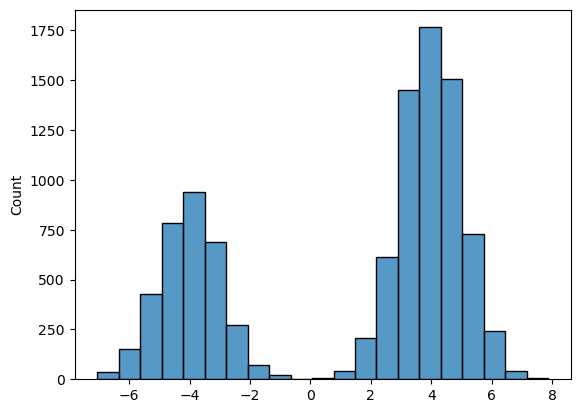

In [23]:
dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set
fig, ax = plt.subplots(1, 1)
sns.histplot(dataset)
plt.savefig("target_distribution.png")
plt.show()

In [24]:
# we will keep these parameters fixed throughout
# these parameters should give you an acceptable result
# but feel free to play with them
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 0.8e-4
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [25]:
# define the neural network that predicts the amount of noise that was
# added to the data
# the network should have two inputs (the current data and the time step)
# and one output (the predicted noise)

class ConditionalModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1)
        )

    def forward(self, x, t):
        # Ensure x and t are column vectors [BATCH_SIZE, 1]
        x = x.view(-1, 1)
        
        # Normalize t between 0 and 1 (helps the network learn better)
        t = t.view(-1, 1).float() / TIME_STEPS 
        
        # Concatenate along the feature dimension to get shape [BATCH_SIZE, 2]
        xt_concat = torch.cat([x, t], dim=1)
        
        # Pass through the network and flatten back to [BATCH_SIZE]
        return self.net(xt_concat).squeeze()

In [26]:
def loss(g, x0, t, noise, beta):
    alphaBar = (1 - beta) ** (t + 1)

    xt = torch.sqrt(alphaBar) * x0 + torch.sqrt(1 - alphaBar) * noise

    predicted_noise = g(xt, t)

    return torch.nn.functional.mse_loss(predicted_noise, noise)

In [27]:
g = ConditionalModel().to(device)

optimizer = torch.optim.Adam(g.parameters(), lr=LEARNING_RATE)


In [28]:
epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar

train_losses = []
validation_losses = []

for e in epochs: # loop over epochs
    total_train_loss = 0.0
    g.train()
    # loop through batches of the dataset, reshuffling it each epoch
    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]
    for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
        # sample a batch of data
        x0 = shuffled_dataset[i:i + BATCH_SIZE]
        
        # here, implement algorithm 1 of the DDPM paper (https://arxiv.org/abs/2006.11239)
        t = torch.randint(0, TIME_STEPS, (BATCH_SIZE,)).to(device)  # sample random time steps
        noise = torch.randn_like(x0).to(device)  # sample noise

        # compute the loss
        optimizer.zero_grad()

        l = loss(g, x0.to(device), t, noise, BETA.to(device))
        l.backward()
        optimizer.step()

        total_train_loss += l.item()

        if (i + 1) % (BATCH_SIZE * 10) == 0:  # print every 10 batches
            epochs.set_description(f"Epoch {e+1}/{N_EPOCHS}, Loss: {total_train_loss / (i + 1):.4f}")


    # print(f"Epoch {e+1}/{N_EPOCHS}, Loss: {total_train_loss / (len(shuffled_dataset) // BATCH_SIZE):.4f}")

    avg_train_loss = total_train_loss / (len(shuffled_dataset) // BATCH_SIZE)
    train_losses.append(avg_train_loss)

    # compute the loss on the validation set
    g.eval()
    total_validation_loss = 0.0

    with torch.no_grad():
        for i in range(0, dataset_validation.shape[0] - BATCH_SIZE, BATCH_SIZE):
            x0 = dataset_validation[i:i + BATCH_SIZE]
            t = torch.randint(0, TIME_STEPS, (BATCH_SIZE,)).to(device)  # sample random time steps
            noise = torch.randn_like(x0).to(device)  # sample noise
            # compute the validation loss
            l = loss(g, x0.to(device), t, noise, BETA.to(device))
            total_validation_loss += l.item()
    # print(f"Validation Loss: {total_validation_loss / (len(dataset_validation) // BATCH_SIZE):.4f}")

    avg_val_loss = total_validation_loss / (len(dataset_validation) // BATCH_SIZE)
    validation_losses.append(avg_val_loss)

    epochs.set_postfix(Train_Loss=f"{avg_train_loss:.4f}", Val_Loss=f"{avg_val_loss:.4f}")

# Create a dictionary containing everything you want to save
checkpoint = {
    'model_state_dict': g.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'validation_losses': validation_losses
}

# Save the dictionary to a file
torch.save(checkpoint, 'diffusion_checkpoint.pth')
print("Model and losses saved to 'diffusion_checkpoint.pth'")

  0%|          | 0/1000 [00:00<?, ?it/s]

Model and losses saved to 'diffusion_checkpoint.pth'


In [ ]:
def sample_reverse(g, count):
    """
    Sample from the model by applying the reverse diffusion process

    Here, implement algorithm 2 of the DDPM paper (https://arxiv.org/abs/2006.11239)

    Parameters
    ----------
    g : torch.nn.Module
        The neural network that predicts the noise added to the data
    count : int
        The number of samples to generate in parallel

    Returns
    -------
    xT : torch.Tensor
        The final sample from the model
    """
    g.eval()
    alphaBar = (1 - BETA) ** (t + 1)
    with torch.no_grad():
        xT = torch.randn(count).to(device)  # start from pure noise

        for t in reversed(range(TIME_STEPS)):
            
            t_tensor = torch.full((count,), t, device=device, dtype=torch.long)  # create a tensor of the current time step

            if t > 0:
                z = torch.randn_like(xT).to(device)  # sample noise for the reverse step
            else:
                z = torch.zeros_like(xT).to(device)  # no noise at the final step

            predicted_noise = g(xT, t_tensor)  # predict the noise at the current

            xT = 1 / torch.sqrt(1 - BETA) * (xT - (BETA / torch.sqrt(1 - alphaBar) * predicted_noise)) + torch.sqrt(BETA) * z  # reverse diffusion step


    return xT.cpu().detach().numpy()

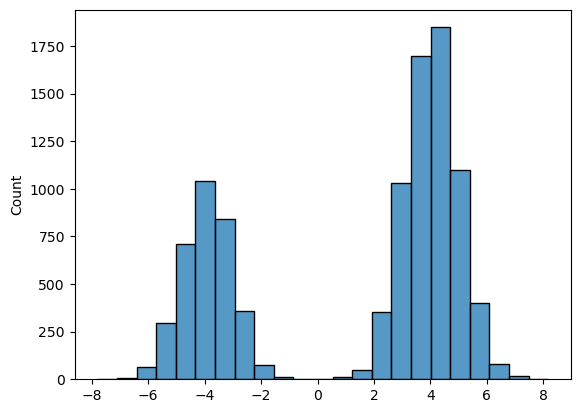

In [30]:
# test the sampling function
samples = sample_reverse(g, 10000)
sns.histplot(samples)
plt.savefig("generated_samples.png")
plt.show()

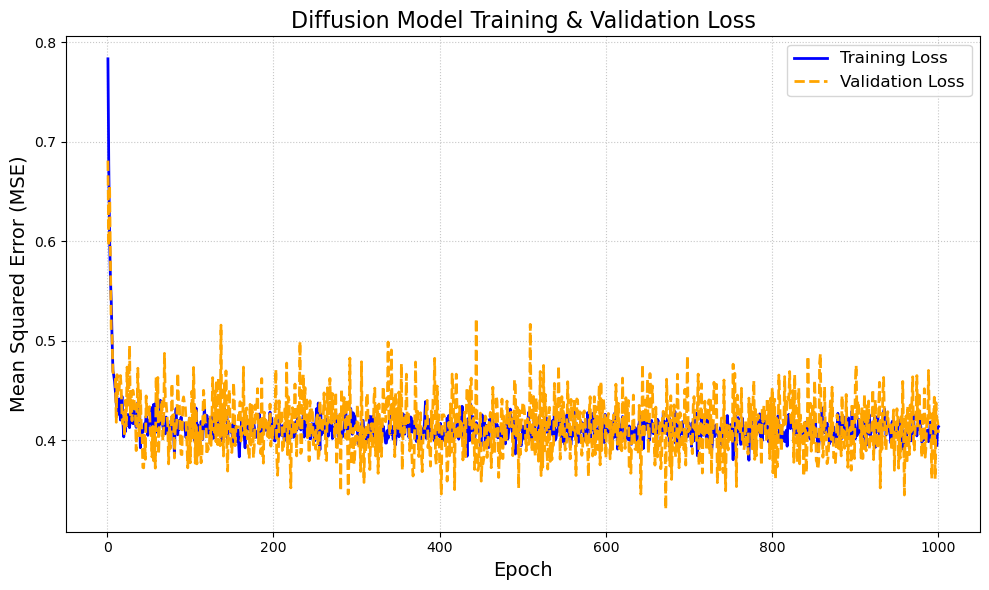

In [31]:
# plot losses
checkpoint = torch.load('diffusion_checkpoint.pth', weights_only=True)

train_losses = checkpoint['train_losses']
validation_losses = checkpoint['validation_losses']

plt.figure(figsize=(10, 6))

# Plot training and validation losses

epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, validation_losses, label='Validation Loss', color='orange', linewidth=2, linestyle='--')

# 4. Format the plot to make it look professional
plt.title('Diffusion Model Training & Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# plt.ylim(0, max(validation_losses[-1] * 3, train_losses[-1] * 3)) 

# 5. Show the plot
plt.tight_layout()
plt.savefig("training_validation_loss_simple_diffusion.png")
plt.show()

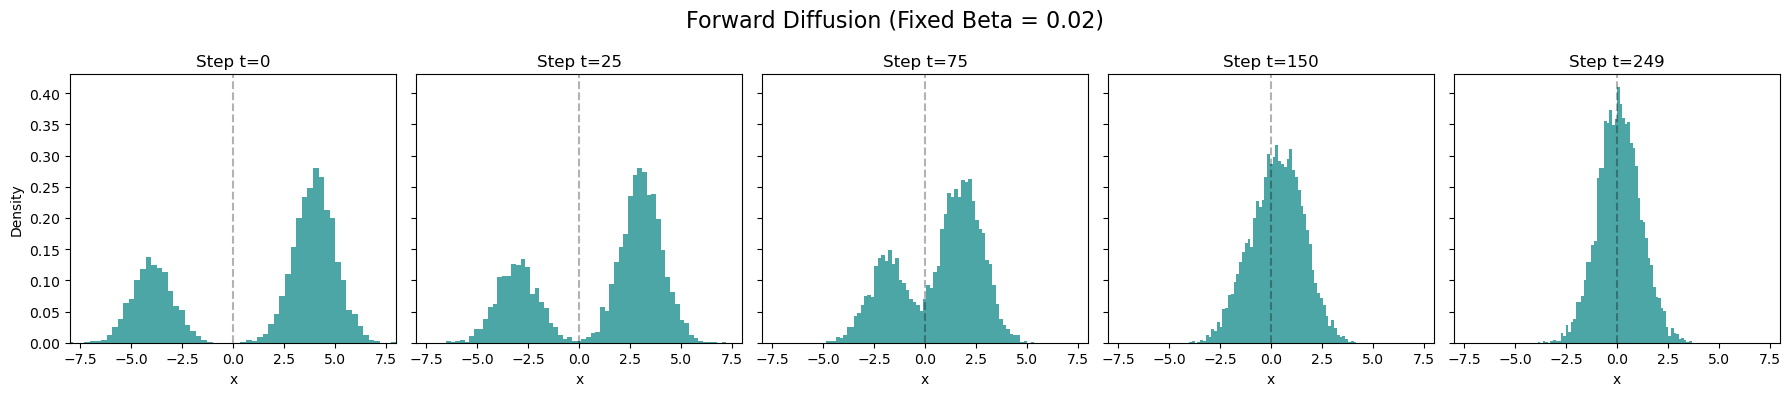

In [ ]:
# Create a tensor where every step has the exact same beta value
beta = torch.full((TIME_STEPS,), BETA)

# Calculate alpha and cumulative alpha (alpha_bar)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)


x_0 = data_distribution.sample((5000,))

# 3. Define the closed-form forward diffusion step
def q_sample(x_0, t):
    """Adds correct amount of noise for timestep t"""
    noise = torch.randn_like(x_0)
    a_bar_t = alpha_bar[t]
    
    # The closed-form formula:
    x_t = torch.sqrt(a_bar_t) * x_0 + torch.sqrt(1 - a_bar_t) * noise
    return x_t

# 4. Plot the transformation at specific timesteps
timesteps_to_plot = [0, 25, 75, 150, 249]
fig, axes = plt.subplots(1, len(timesteps_to_plot), figsize=(18, 4), sharex=True, sharey=True)

for i, t in enumerate(timesteps_to_plot):
    if t == 0:
        x_t = x_0  # No noise at t=0
    else:
        t_tensor = torch.full((len(x_0),), t, dtype=torch.long)
        x_t = q_sample(x_0, t_tensor)

    # Plot the histogram
    axes[i].hist(x_t.numpy(), bins=60, density=True, alpha=0.7, color='teal')
    axes[i].set_title(f"Step t={t}")
    axes[i].set_xlabel("x")
    axes[i].axvline(0, color='black', linestyle='--', alpha=0.3)

axes[0].set_ylabel("Density")
plt.suptitle("Forward Diffusion (Fixed Beta = 0.02)", fontsize=16)
plt.xlim(-8, 8)
plt.tight_layout()
plt.savefig("forward_diffusion_progression.png")
plt.show()

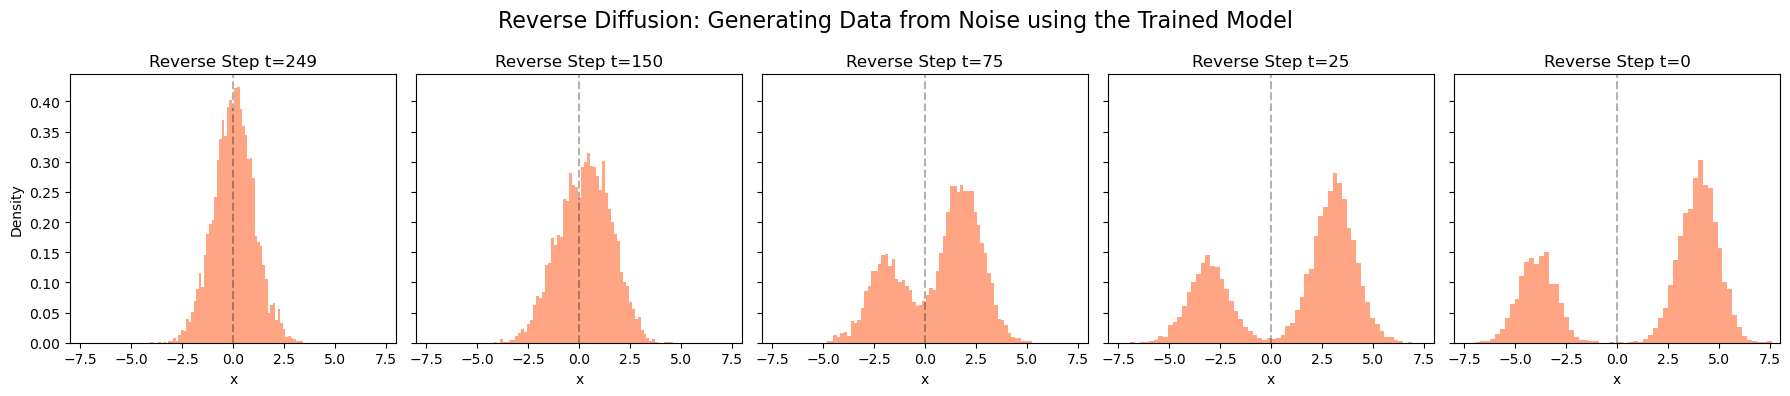

In [33]:


def sample_and_plot_reverse(g, count=5000):
    # Ensure the model is in evaluation mode
    g.eval()
    
    # The specific timesteps we want to capture to see the progression
    timesteps_to_plot = [249, 150, 75, 25, 0]
    
    # Dictionary to hold the state of our samples at these specific steps
    saved_states = {}
    
    with torch.no_grad():
        x = torch.randn(count).to(device)  # Start from pure standard normal noise
        
        # Save the initial pure noise state
        saved_states[TIME_STEPS - 1] = x.cpu().numpy().copy()
        
        for t in reversed(range(TIME_STEPS)):
            # Create batched time tensor for the network
            t_tensor = torch.full((count,), t, device=device, dtype=torch.long)
            
            if t > 0:
                z = torch.randn_like(x).to(device)
            else:
                z = torch.zeros_like(x).to(device)
                
            # Calculate alphaBar using your fixed BETA
            beta_val = BETA.to(device)
            alphaBar = (1 - beta_val) ** (t + 1) 
            
            # The network predicts the noise it thinks is in the data
            predicted_noise = g(x, t_tensor)
            
            # Remove a fraction of that noise (Algorithm 2, step 4)
            x = 1 / torch.sqrt(1 - beta_val) * (x - (beta_val / torch.sqrt(1 - alphaBar)) * predicted_noise) + torch.sqrt(beta_val) * z
            
            # Save the state if we reach one of our target timesteps
            if t in timesteps_to_plot and t != (TIME_STEPS - 1):
                saved_states[t] = x.cpu().numpy().copy()
                
    # --- Plotting the Results ---
    fig, axes = plt.subplots(1, len(timesteps_to_plot), figsize=(18, 4), sharex=True, sharey=True)
    
    for i, t in enumerate(timesteps_to_plot):
        data = saved_states[t]
        axes[i].hist(data, bins=60, density=True, alpha=0.7, color='coral')
        axes[i].set_title(f"Reverse Step t={t}")
        axes[i].set_xlabel("x")
        axes[i].axvline(0, color='black', linestyle='--', alpha=0.3)
        
    axes[0].set_ylabel("Density")
    plt.suptitle("Reverse Diffusion: Generating Data from Noise using the Trained Model", fontsize=16)
    plt.xlim(-8, 8)
    plt.tight_layout()
    plt.savefig("reverse_diffusion_progression.png")
    plt.show()

# Run the visualization
sample_and_plot_reverse(g)